## 1. Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import lightgbm as lgb
import pickle

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# Mostrar gráficos en la misma celda
%matplotlib inline

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Carga de datos y creacion del dataframe

In [2]:
path = r'C:\Users\Javier2\Desktop\Javier\Data Science\Proyectos\Forecasting_01'

nombre_fichero_datos = ['train.csv', 'stores.csv', 'oil.csv', 'holidays_events.csv', 'transactions.csv', 'test.csv', 'sample_submission.csv']

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[0]
train = pd.read_csv(ruta_completa, index_col = 0)
train['date'] = pd.to_datetime(train['date'])

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[1]
stores = pd.read_csv(ruta_completa)

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[2]
oil = pd.read_csv(ruta_completa)
oil['date'] = pd.to_datetime(oil['date'])

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[3]
holidays = pd.read_csv(ruta_completa)
holidays['date'] = pd.to_datetime(holidays['date'])

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[4]
transactions = pd.read_csv(ruta_completa)
transactions['date'] = pd.to_datetime(transactions['date'])

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[5]
test = pd.read_csv(ruta_completa)
test['date'] = pd.to_datetime(test['date'])

ruta_completa = path + '/02_Datos/01_Originales/' + nombre_fichero_datos[6]
sample = pd.read_csv(ruta_completa, index_col = 0)

### 2.1. Oil

In [3]:
oil.isna().sum()

date           0
dcoilwtico    43
dtype: int64

In [4]:
oil = oil.set_index('date')
oil = oil.resample('D').asfreq()
oil['precio'] = oil.dcoilwtico.rolling(6, min_periods = 2, center = True).mean()

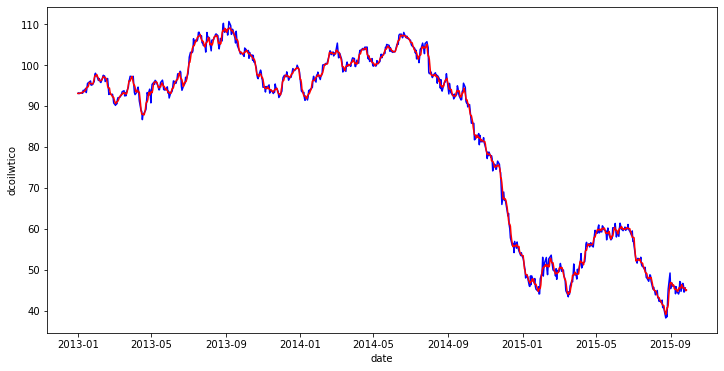

In [5]:
plt.figure(figsize = (12,6))
sns.lineplot(data = oil.iloc[:1000], x = oil.iloc[:1000].index, y = 'dcoilwtico', color = 'blue')
sns.lineplot(data = oil.iloc[:1000], x = oil.iloc[:1000].index, y = 'precio', color = 'red')
oil = oil.drop(columns = ['dcoilwtico'])

### 2.2. Holidays

In [6]:
holidays.loc[holidays.date == '2014-06-25']

,date,type,locale,locale_name,description,transferred
110,2014-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
111,2014-06-25,Holiday,Local,Machala,Fundacion de Machala,False
112,2014-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
113,2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False


Existen ciertos dias en los que hay mas de un festivo. He decidido quedarme con el que aparece ultimo que es el que parece que tiene mas importancia, aunque tampoco creo que influya mucho.

In [7]:
holidays = holidays.drop_duplicates(subset = 'date', keep = 'last')

### 2.3. Unir dataframes

In [8]:
train = pd.merge(left = train, right = stores, how = 'left', on = 'store_nbr')
train = pd.merge(left = train, right = oil.reset_index(), how = 'left', on = 'date')
train = pd.merge(left = train, right = holidays, how = 'left', on = 'date')
train.drop_duplicates(subset = ['date', 'store_nbr', 'family'], keep = 'first', inplace = True)
train = train.reset_index(drop = True)
train = train.rename(columns = {'type_x':'tipo_store', 'type_y':'tipo_holiday'})
train['test'] = 0
print(train.shape)
train.head()

(3000888, 16)


,date,store_nbr,family,sales,onpromotion,city,state,tipo_store,cluster,precio,tipo_holiday,locale,locale_name,description,transferred,test
0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0
1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0
2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0
3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0
4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0


#### Hacer lo mismo con test

In [9]:
test = pd.merge(left = test, right = stores, how = 'left', on = 'store_nbr')
test = pd.merge(left = test, right = oil.reset_index(), how = 'left', on = 'date')
test = pd.merge(left = test, right = holidays, how = 'left', on = 'date')
test.drop_duplicates(subset = ['date', 'store_nbr', 'family'], keep = 'first', inplace = True)
test = test.reset_index(drop = True)
test = test.rename(columns = {'type_x':'tipo_store', 'type_y':'tipo_holiday'})
test['test'] = 1
print(test.shape)
test.head()

(28512, 16)


,id,date,store_nbr,family,onpromotion,city,state,tipo_store,cluster,precio,tipo_holiday,locale,locale_name,description,transferred,test
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,47.52,NaN,NaN,NaN,NaN,NaN,1
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,47.52,NaN,NaN,NaN,NaN,NaN,1
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,47.52,NaN,NaN,NaN,NaN,NaN,1
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,47.52,NaN,NaN,NaN,NaN,NaN,1
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,47.52,NaN,NaN,NaN,NaN,NaN,1


In [10]:
df = pd.concat([train, test], axis = 0)
df

,date,store_nbr,family,sales,onpromotion,city,state,tipo_store,cluster,precio,tipo_holiday,locale,locale_name,description,transferred,test,id
0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0,NaN
1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0,NaN
2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0,NaN
3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0,NaN
4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13,93.06,Holiday,National,Ecuador,Primer dia del ano,False,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28507,2017-08-31,9,POULTRY,NaN,1,Quito,Pichincha,B,6,46.52,NaN,NaN,NaN,NaN,NaN,1,3029395.00
28508,2017-08-31,9,PREPARED FOODS,NaN,0,Quito,Pichincha,B,6,46.52,NaN,NaN,NaN,NaN,NaN,1,3029396.00
28509,2017-08-31,9,PRODUCE,NaN,1,Quito,Pichincha,B,6,46.52,NaN,NaN,NaN,NaN,NaN,1,3029397.00
28510,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,NaN,9,Quito,Pichincha,B,6,46.52,NaN,NaN,NaN,NaN,NaN,1,3029398.00


# 3. EDA

#### Tendencia global de las ventas

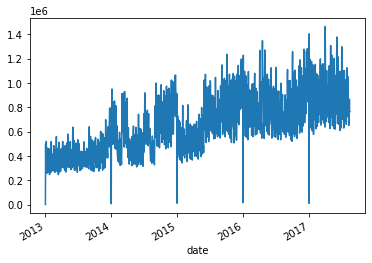

In [11]:
train.groupby('date').sales.sum().plot();

#### Tendencia de las ventas por familia

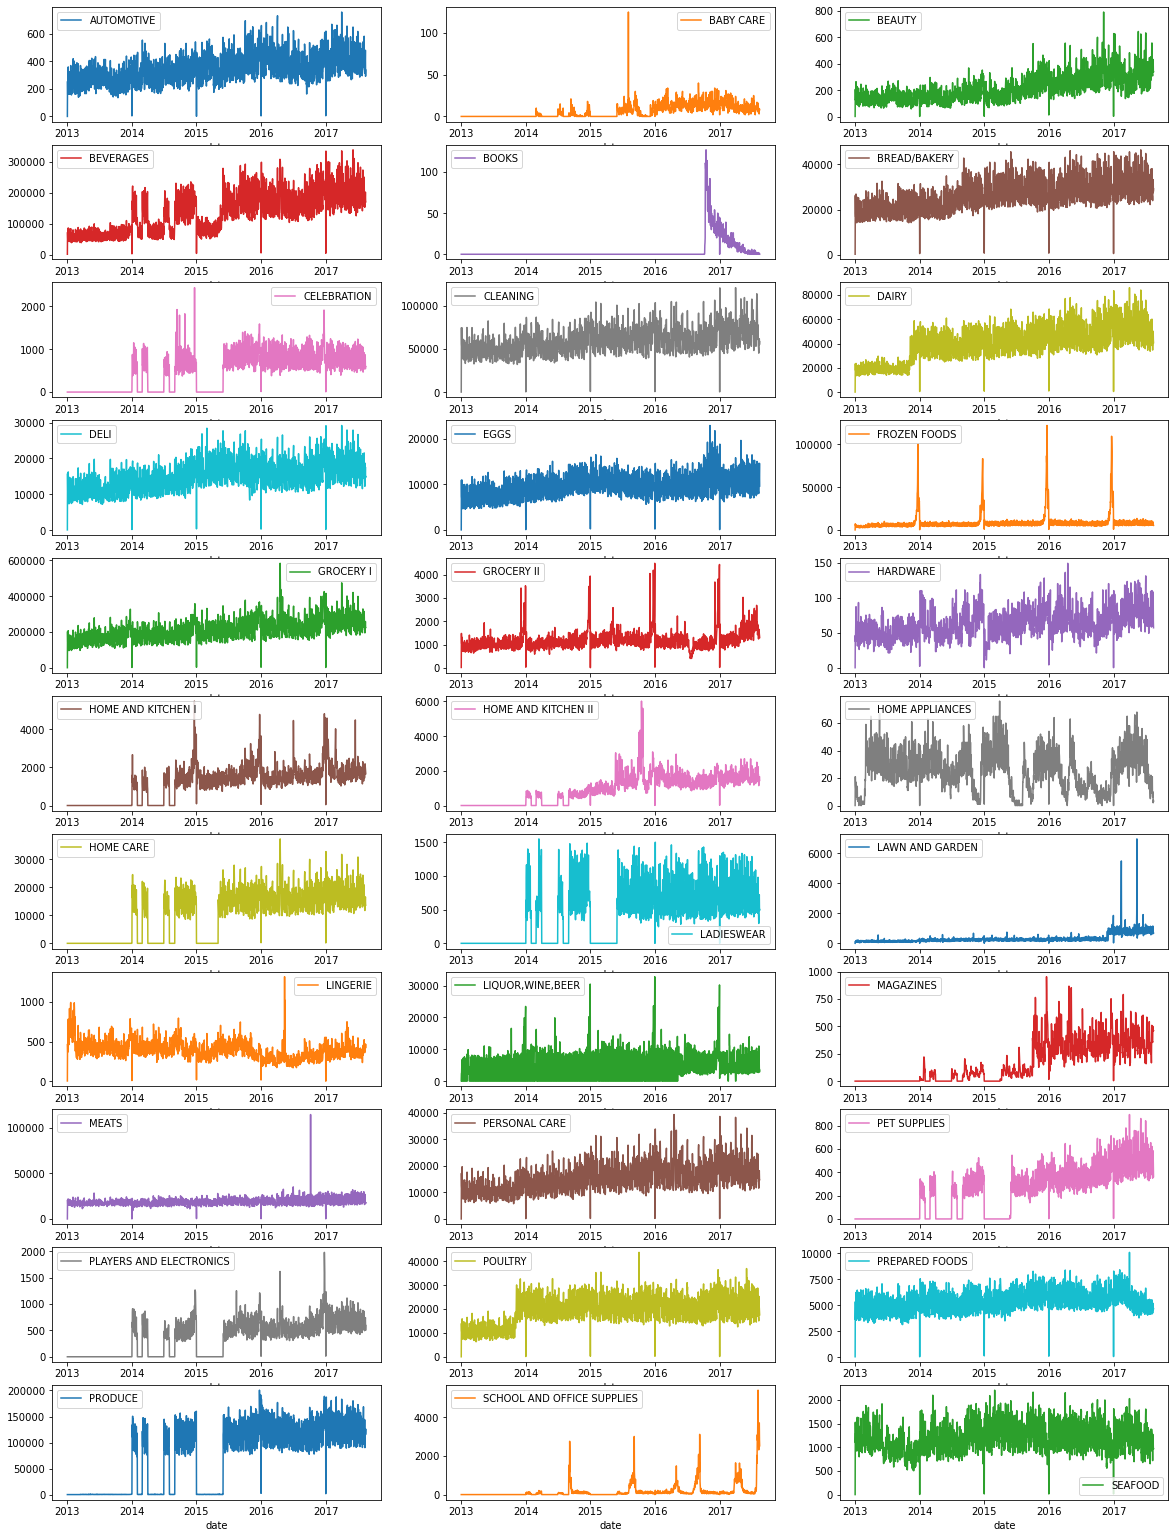

In [12]:
train.groupby(['date','family']).sales.sum().unstack().plot(subplots = True,  layout = (12,3), sharex=False, figsize=(20,30));

Vemos que en muchas familias ocurre la llamada demanda intermitente, en la que las ventas para algunos dias son 0, pero no sabemos si es porque no han habido ventas o si son nulos debido o a que el producto no estaba disponible, no estaba en venta todavía o si se produjo una rotura de stock.

Lo que sorprende es que se produce siempre en las mismas fechas sin importar la familia. Todo 2013 son ventas 0, no sabemos si es porque el producto todavia no lo habian lanzado al mercado. Posteriormente todo el 2014 y hasta la mitad del 2015 hay periodos donde hay ventas 0, pero en muchas familias.

Se podria solucionar con las variables que añadire mas tarde de lags en las ventas.

#### Tendencia de las ventas por tienda

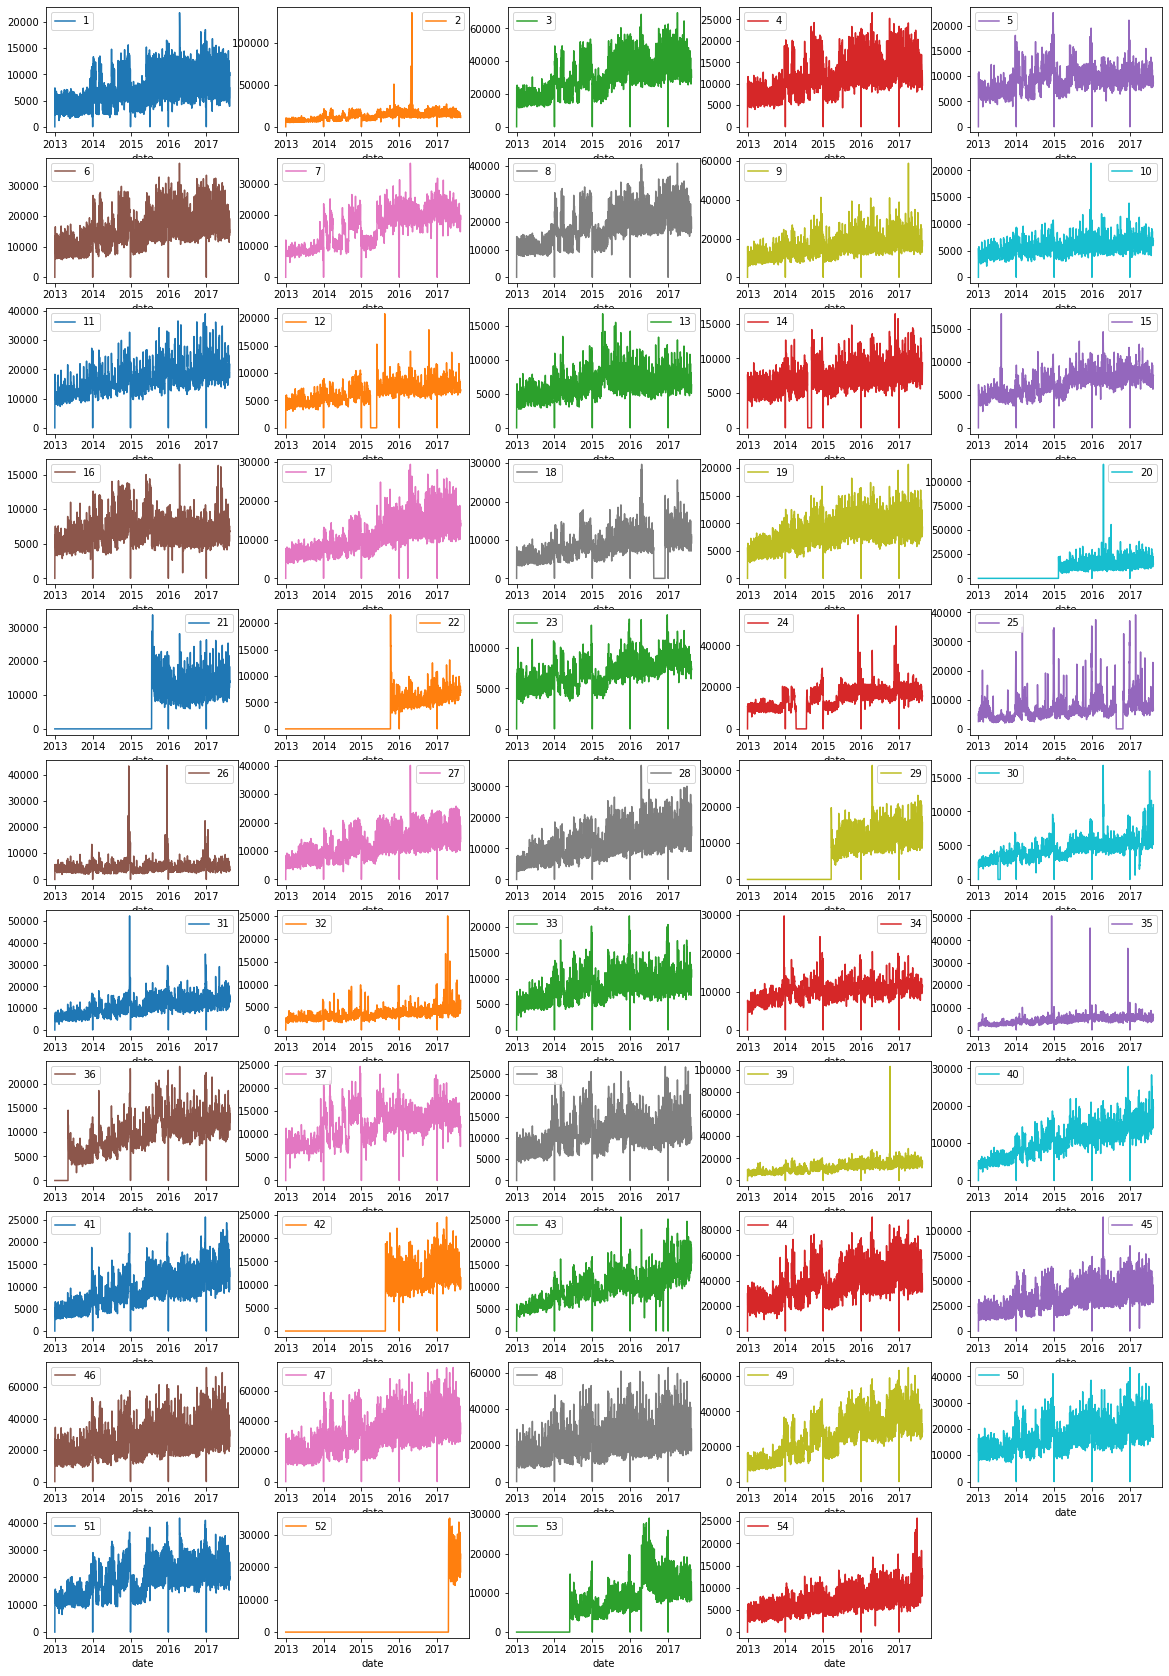

In [13]:
train.groupby(['date','store_nbr']).sales.sum().unstack().plot(subplots = True,  layout = (11,5), sharex=False, figsize=(20,30));

Vemos que hay tiendas que al principio no tienen ventas, probablemente sea porque no habian abierto todavia. Tambien tenemos que crear una variable para solucionar este problema.

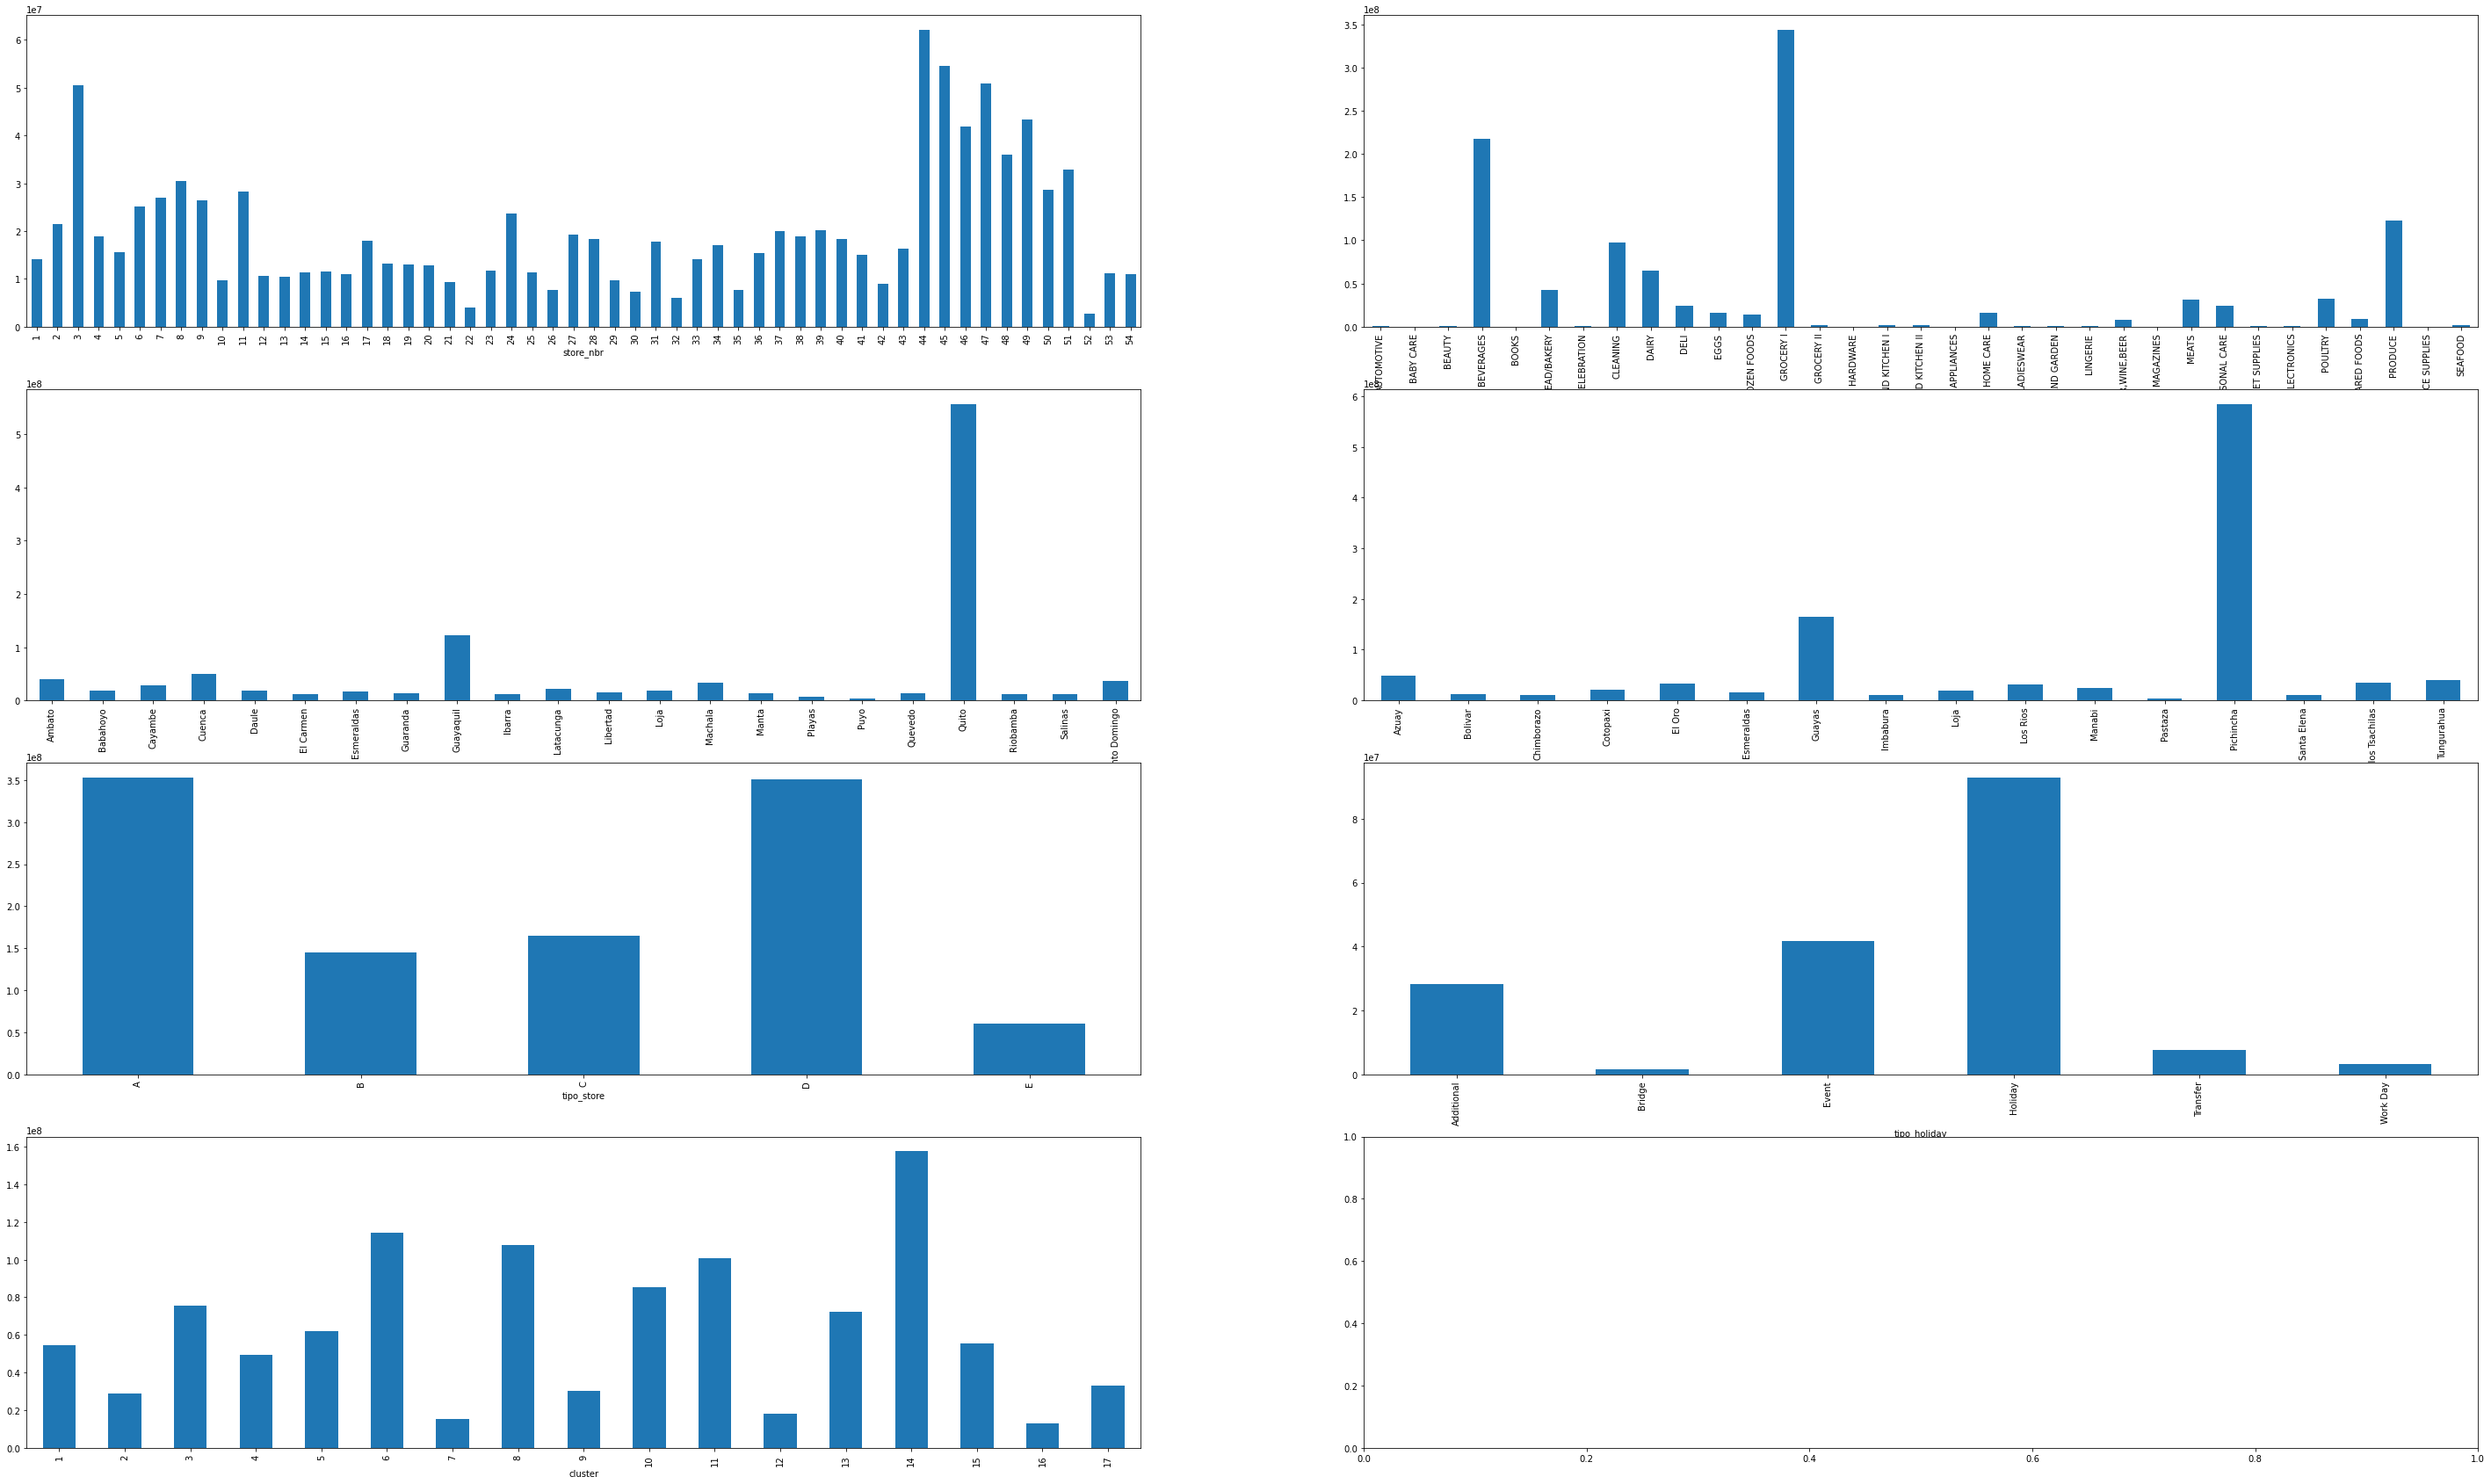

In [14]:
variables_analizar = ['store_nbr', 'family', 'city', 'state', 'tipo_store', 'tipo_holiday', 'cluster']

f, ax = plt.subplots(4, 2, figsize = (50, 30))
ax = ax.flatten()

for n, var in enumerate(variables_analizar):
    temp = train.groupby(var).sales.sum()
    temp.plot(kind = 'bar', ax = ax[n]);

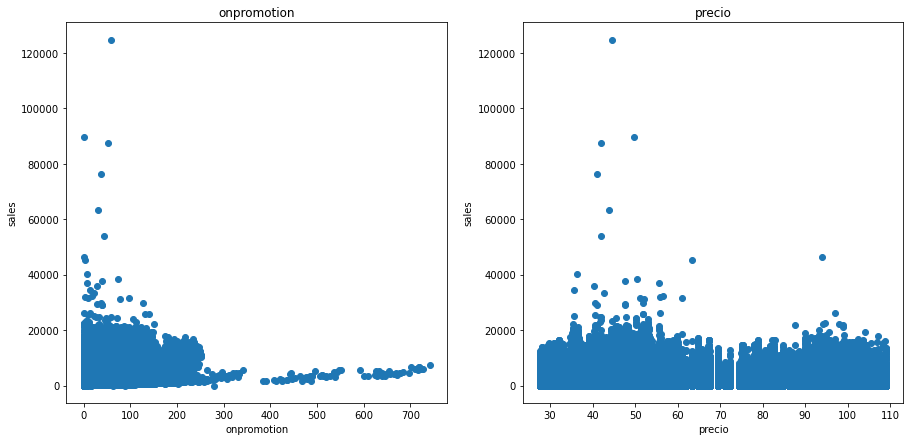

In [15]:
variables_analizar_sct = ['onpromotion', 'precio']

f, ax = plt.subplots(1, 2, figsize = (15, 7))
ax = ax.flatten()

for n, var in enumerate(variables_analizar_sct):
    ax[n].scatter(x = train[var], y = train['sales'])
    ax[n].set_title(var)
    ax[n].set_xlabel(var)
    ax[n].set_ylabel('sales');

#  4. Limpiar los datasets

In [16]:
df.isna().sum().sort_values(ascending = False)

id              3000888
transferred     2578554
description     2578554
locale_name     2578554
locale          2578554
tipo_holiday    2578554
sales             28512
precio                0
test                  0
date                  0
store_nbr             0
tipo_store            0
state                 0
city                  0
onpromotion           0
family                0
cluster               0
dtype: int64

Estos nulos no tienen importancia, ya que:
- id: sus nulos son los de train, ya que el dataset de train inicial no tenia esta columna
- sales: sus nulos son los de test y son justamente los que tenemos que predecir
- El resto de columnas son de holidays y son nulos porque esos dias no hubo festivos

#### 4.1. Limpiar holidays

In [17]:
df.description.value_counts(ascending = False).head(20)

Carnaval                         17820
Fundacion de Cuenca              10692
Primer dia del ano                8910
Dia de la Madre                   8910
Fundacion de Ambato               8910
Fundacion de Riobamba             8910
Primer Grito de Independencia     8910
Fundacion de Esmeraldas           8910
Fundacion de Guayaquil            8910
Cantonizacion de Cayambe          8910
Fundacion de Santo Domingo        8910
Batalla de Pichincha              8910
Cantonizacion de Guaranda         8910
Viernes Santo                     8910
Provincializacion de Cotopaxi     8910
Fundacion de Manta                8910
Navidad-2                         7128
Independencia de Cuenca           7128
Navidad-4                         7128
Navidad-1                         7128
Name: description, dtype: int64

Festivos a añadir:
- Navidad
- Primer dia del año
- Carnaval
- Terremoto
- Dia de la Madre y del Padre
- Fundacion de Cuenca
- Viernes Santo

In [18]:
df['holiday_navidad'] = df.description.apply(lambda x: 1 if 'navidad' in str(x).lower() else 0)
df['holiday_carnaval'] = df.description.apply(lambda x: 1 if 'carnaval' in str(x).lower() else 0)
df['holiday_dia_padre_madre'] = df.description.apply(lambda x: 1 if 'dia de la madre' in str(x).lower() or 'dia del padre' in str(x).lower() else 0)
df['holiday_cuenca'] = df.description.apply(lambda x: 1 if 'fundacion de cuenca' in str(x).lower() else 0)
df['holiday_viernes_santo'] = df.description.apply(lambda x: 1 if 'viernes santo' in str(x).lower() else 0)

In [19]:
df['holiday_primer_dia_ano'] = 0
df.loc[(df.date.dt.month == 1) & (df.date.dt.day == 1), 'holiday_primer_dia_ano'] = 1

## 5. Creacion de variables

#### 5.1. Componentes de la fecha

In [20]:
df['day_of_week'] = df['date'].dt.day_of_week
df['day_of_year'] = df['date'].dt.dayofyear
df['day_of_month'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year

##### 5.2. Un terremoto de magnitud 7,8 sacudió Ecuador el 16 de abril de 2016

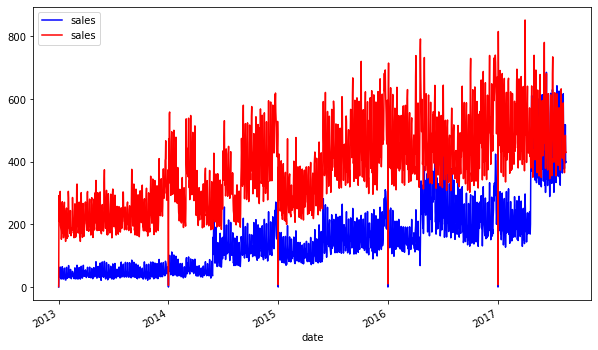

In [21]:
# El terremoto tuvo lugar en el estado de Manabí.

manabi = df.loc[df.state == 'Manabi'].groupby('date')[['sales']].mean()
resto = df.loc[df.state != 'Manabi'].groupby('date')[['sales']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
manabi.plot(color='blue', label='Manabi', ax=ax)
resto.plot(color='red', label='Resto', ax=ax);

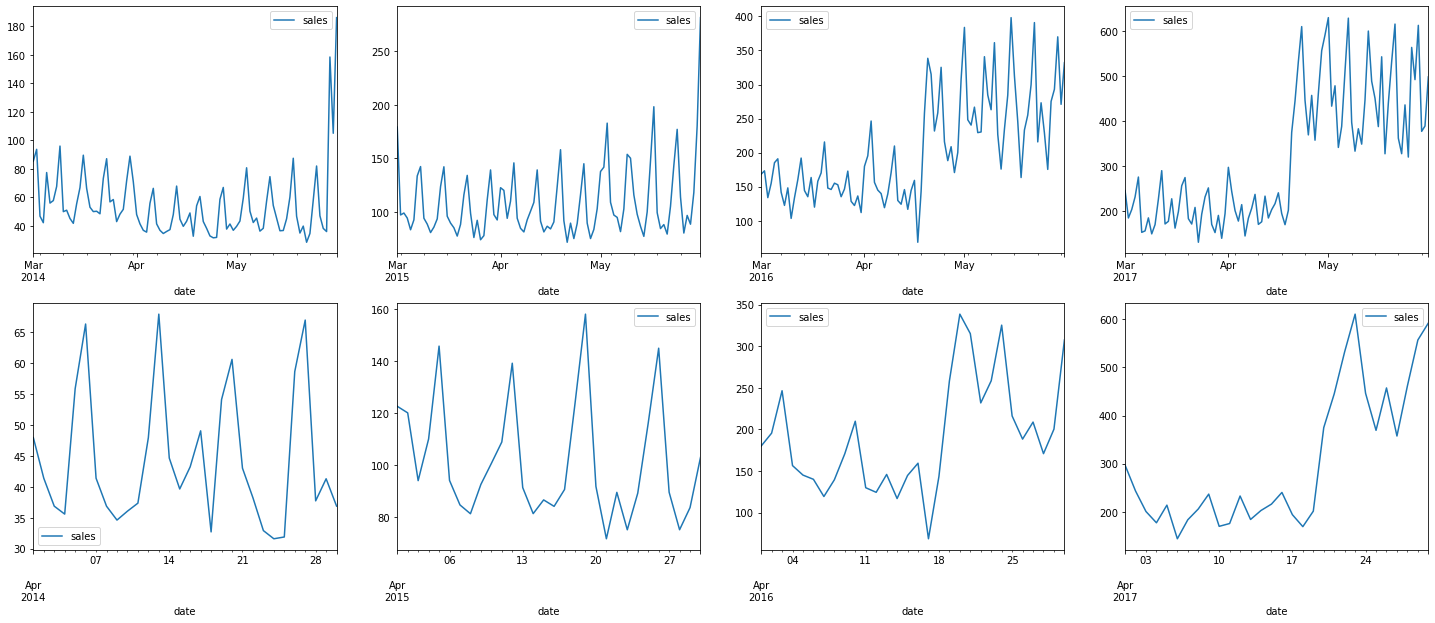

In [22]:
f, ax = plt.subplots(2, 4, figsize = (25, 10))
manabi.loc['2014-03':'2014-05'].plot(ax = ax[0, 0])
manabi.loc['2015-03':'2015-05'].plot(ax = ax[0, 1])
manabi.loc['2016-03':'2016-05'].plot(ax = ax[0, 2])
manabi.loc['2017-03':'2017-05'].plot(ax = ax[0, 3])
manabi.loc['2014-04'].plot(ax = ax[1, 0])
manabi.loc['2015-04'].plot(ax = ax[1, 1])
manabi.loc['2016-04'].plot(ax = ax[1, 2])
manabi.loc['2017-04'].plot(ax = ax[1, 3]);

In [23]:
df['terremoto'] = 0

df.loc[(df.description.str.contains('Terremoto')) & (df.state == 'Manabi'), 'terremoto'] = 1

In [24]:
df = df.drop(columns = ['tipo_holiday', 'locale', 'locale_name', 'description', 'transferred'])

#### 5.3. Los salarios en el sector público se pagan cada dos semanas el día 15 y el último día del mes

In [25]:
def salarios(x):
    if x.date.is_month_end or x.day_of_month == 15:
        return 1
    else: 
        return 0
    
df['salarios'] = df.apply(salarios, axis = 1)

#### 5.4. Variable para saber si la tienda ha abierto

In [26]:
df['abierta'] = 0

for tienda in df['store_nbr'].unique():
    primer_dia_venta = df.loc[(df['store_nbr'] == tienda) & (df.sales > 0)].head(1).date.dt.strftime('%Y-%m-%d').iloc[0]
    df.loc[(df['store_nbr'] == tienda) & (df.date >= primer_dia_venta), 'abierta'] = 1

#### 5.5. Lags en las ventas

In [27]:
df_agrupado = df.groupby(['store_nbr', 'family'])

alphas = [0.95, 0.8, 0.65, 0.5]
lags =[1,7,30]

for a in alphas:
    for i in lags:
        df[f'sales_lag_{i}_alpha_{a}'] = np.log1p(df_agrupado['sales'].transform(lambda x: x.shift(i).ewm(alpha=a, min_periods=1).mean()))

## 6. Transformación de datos

#### One Hot Encoding

In [28]:
cat = ['city', 'state', 'tipo_store', 'store_nbr']
df = pd.get_dummies(df, columns=cat, drop_first=True)
df.head()

,date,family,sales,onpromotion,cluster,precio,test,id,holiday_navidad,holiday_carnaval,...,store_nbr_45,store_nbr_46,store_nbr_47,store_nbr_48,store_nbr_49,store_nbr_50,store_nbr_51,store_nbr_52,store_nbr_53,store_nbr_54
0,2013-01-01,AUTOMOTIVE,0.00,0,13,93.06,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2013-01-01,BABY CARE,0.00,0,13,93.06,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2013-01-01,BEAUTY,0.00,0,13,93.06,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2013-01-01,BEVERAGES,0.00,0,13,93.06,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2013-01-01,BOOKS,0.00,0,13,93.06,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
df.isna().sum().sort_values(ascending = False).head(30)

id                         3000888
sales_lag_30_alpha_0.65      53460
sales_lag_30_alpha_0.95      53460
sales_lag_30_alpha_0.8       53460
sales_lag_30_alpha_0.5       53460
sales                        28512
sales_lag_7_alpha_0.5        12474
sales_lag_7_alpha_0.95       12474
sales_lag_7_alpha_0.8        12474
sales_lag_7_alpha_0.65       12474
sales_lag_1_alpha_0.8         1782
sales_lag_1_alpha_0.65        1782
sales_lag_1_alpha_0.95        1782
sales_lag_1_alpha_0.5         1782
store_nbr_18                     0
store_nbr_19                     0
store_nbr_20                     0
store_nbr_21                     0
store_nbr_22                     0
store_nbr_23                     0
store_nbr_24                     0
date                             0
store_nbr_17                     0
store_nbr_26                     0
store_nbr_7                      0
tipo_store_D                     0
tipo_store_E                     0
store_nbr_2                      0
store_nbr_3         

In [30]:
sales_lag_columns = list(df.filter(like="lag").columns)

In [31]:
df.dropna(inplace = True, subset = sales_lag_columns)

## 7. Preseleccion de variables

#### Mutual Information

In [32]:
def ranking_mi(mutual_selector, modo = 'tabla'):
    #Maqueta el ranking
    ranking_mi = pd.DataFrame(mutual_selector, index = x.columns).reset_index()
    ranking_mi.columns = ['variable','importancia_mi']
    ranking_mi = ranking_mi.sort_values(by = 'importancia_mi', ascending = False)
    ranking_mi['ranking_mi'] = np.arange(0,ranking_mi.shape[0])
    #Muestra la salida
    if modo == 'tabla':
        return(ranking_mi)
    else:
        g = ranking_mi.importancia_mi.sort_values().plot.barh(figsize = (12,20))
        g.set_yticklabels(ranking_mi.sort_values(by = 'importancia_mi').variable)
        return(g)

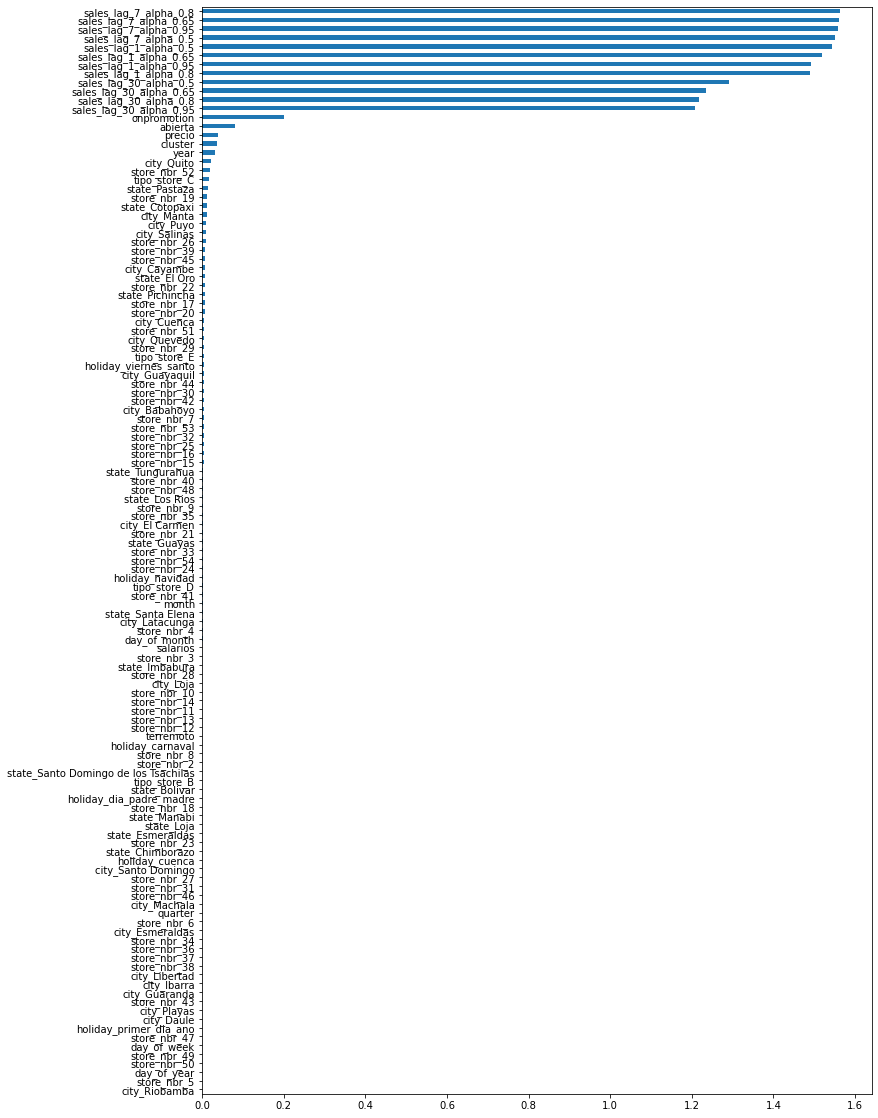

In [33]:
muestra = df.loc[df.test == 0].sample(n=10000, replace=False)

x = muestra.drop(columns = ['sales', 'date', 'id', 'test', 'family'])
y = muestra['sales']

mutual_selector = mutual_info_regression(x,y)

rank_mi = ranking_mi(mutual_selector, modo = 'grafico')

In [34]:
ranking_mi(mutual_selector).reset_index()[20:65]

,index,variable,importancia_mi,ranking_mi
20,61,state_Pastaza,0.01,20
21,87,store_nbr_19,0.01,21
22,53,state_Cotopaxi,0.01,22
23,43,city_Manta,0.01,23
24,45,city_Puyo,0.01,24
25,49,city_Salinas,0.01,25
26,94,store_nbr_26,0.01,26
27,107,store_nbr_39,0.01,27
28,113,store_nbr_45,0.01,28
29,31,city_Cayambe,0.01,29


In [35]:
variables_finales = ranking_mi(mutual_selector).iloc[0:60].variable.to_list()
variables_finales = ['date', 'family', 'id', 'sales', 'test'] + variables_finales

In [46]:
nombre_var_finales = 'variables_finales.pickle'
ruta_var_finales = path + '/05_Resultados/' + nombre_var_finales
with open(ruta_var_finales, mode='wb') as file:
   pickle.dump(variables_finales, file)

##  6. Modelo

In [36]:
df = df[variables_finales]

In [37]:
def entrenamiento(x, y):
    
    lgbm = lgb.LGBMRegressor()

    grid = {
        'task': ['train'],
        'boosting_type': ['gbdt'],
        'objective': ['regression'],
        'metric': [['l1'], ['l2']],
        'learning_rate': [0.01, 0.025, 0.05, 0.1],
        'feature_fraction': [0.7, 0.8, 0.9, 1.0],
        'bagging_fraction': [0.6, 0.7, 0.8, 0.9, 1.0],
        'bagging_freq': [10],
        'verbose': [0],
        "max_depth": [5, 10, 15, 20],
        "num_leaves": [31, 64, 128, 256],
        "max_bin": [255, 511, 1023],
        "num_iterations": [50, 100, 200, 500, 1000]
        }


    
    from sklearn.metrics import make_scorer

    # Función para calcular RMSLE
    def rmsle(y_true, y_pred):
        return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

    # Crea un objeto scorer para RMSLE
    rmsle_scorer = make_scorer(rmsle, greater_is_better=False)
    
    random_search = RandomizedSearchCV(estimator = lgbm,
                                   param_distributions = grid,
                                   n_iter = 20, 
                                   scoring = rmsle_scorer, 
                                   verbose = 0,
                                   n_jobs = -1)

    modelo = random_search.fit(x,y)
    
    modelo_final = modelo.best_estimator_
    
    return modelo_final

In [38]:
train = df.loc[df.test == 0].copy()
test = df.loc[df.test == 1].copy()

print(train.shape)
print(test.shape)

(2947428, 65)
(28512, 65)


In [39]:
lista_familias = train.family.unique()

dict_modelos = {}

for familia in lista_familias:
    df_familia = train.loc[train.family == familia].sample(frac = 0.2).sort_values('date').drop(columns = ['date', 'family', 'id', 'test'])
    x = df_familia.drop(columns = 'sales')
    y = df_familia.sales
    
    modelo = entrenamiento(x, y)
    dict_modelos[familia] = modelo

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005896 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Warning] No further splits with positive 

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Warning] No further splits with positive 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Warning] No further splits with positive 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [41]:
nombre_modelos = 'dict_modelos.pickle'
ruta_modelos = path + '/04_Modelos/' + nombre_modelos
with open(ruta_modelos, mode='wb') as file:
   pickle.dump(dict_modelos, file)

In [42]:
submission = pd.DataFrame()

for familia in lista_familias:
    x = test.loc[test.family == familia].drop(columns=['date', 'family', 'id', 'sales', 'test'])
    modelo = dict_modelos[familia]
    
    predicciones = modelo.predict(x)
    predicciones_df = pd.DataFrame(data={'predicciones': predicciones}, index=x.index)
    
    submission = pd.concat([submission, predicciones_df], axis=0)

In [43]:
submission

,predicciones
0,4.80
33,2.87
66,6.29
99,4.40
132,4.69
...,...
28379,2.35
28412,46.65
28445,52.38
28478,24.54


In [44]:
submission.insert(0, 'id', test.id)
submission = submission.sort_values('id')
submission['id'] = submission['id'].astype('Int32')
submission = submission.rename(columns = {'predicciones':'sales'})
submission

,id,sales
0,3000888,4.80
1,3000889,0.01
2,3000890,4.68
3,3000891,2304.19
4,3000892,0.05
...,...,...
28507,3029395,404.13
28508,3029396,124.46
28509,3029397,2382.99
28510,3029398,46.32


In [45]:
submission.to_csv('submission_final.csv', index=False) 

Estas predicciones me dan un RMSLE (Root Mean Squared Logarithmic Error) de 0.49